# 01. A grid-following inverter and its analogue phase-locked loop

A grid-following inverter pushes power into a live grid, so it cannot impose its
own voltage and frequency. It has to measure the grid and steer its output to
match. This notebook simulates one in the time domain as four cascaded stages,
and watches the closed loop pull into step with a 50 Hz reference.

Every stage is there for a reason. The **boost converter** lifts a low dc source
to a usable link voltage, because the bridge can only ever output a fraction of
its own supply. The **sinusoidal PWM modulator** chops that link into a train
of pulses whose widths trace a sine, building a mains-frequency waveform out of
hard switching. The **output filter** strips the switching ripple and leaves
the sinusoid behind. The **phase-locked loop**, the PLL, compares that sinusoid
against the grid reference and returns a frequency correction, fed back into the
modulator so the output tracks the grid in phase. Take the loop away and the
inverter free-runs at its nominal frequency and drifts. Leave it in and the
output synchronises, then holds.

The integration is expensive (a 2 MHz carrier resolved over half a second of
simulated time), so it runs once in `scripts/run_simulation.py` and this
notebook just reads the recorded waveforms.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from invertermodel.config import load_config
from invertermodel.plotting import palette, save_figure, setup_style

setup_style()
cfg = load_config()

artifacts = np.load(cfg.paths.artifacts / "sim.npz")
meta = json.loads((cfg.paths.artifacts / "sim_meta.json").read_text())

time = artifacts["time"].astype(float)
time_ms = time * 1.0e3
settle = meta["settle_index"]
dt = float(np.mean(np.diff(time)))


def thin(*series: np.ndarray, step: int) -> tuple[np.ndarray, ...]:
    """Subsample long records so a whole-horizon plot stays light."""
    return tuple(s[::step] for s in series)

## The boost stage sets the dc link

Start at the front of the chain. The converter switches at 2 MHz with a
half-and-half duty cycle, charging the inductor from the 2.5 V source and
dumping it into the output capacitor. The capacitor voltage climbs and settles
at the stepped-up link level the bridge then draws on. The trace is thinned for
display: the fine switching ripple sits well below the resolution of a
half-second view.

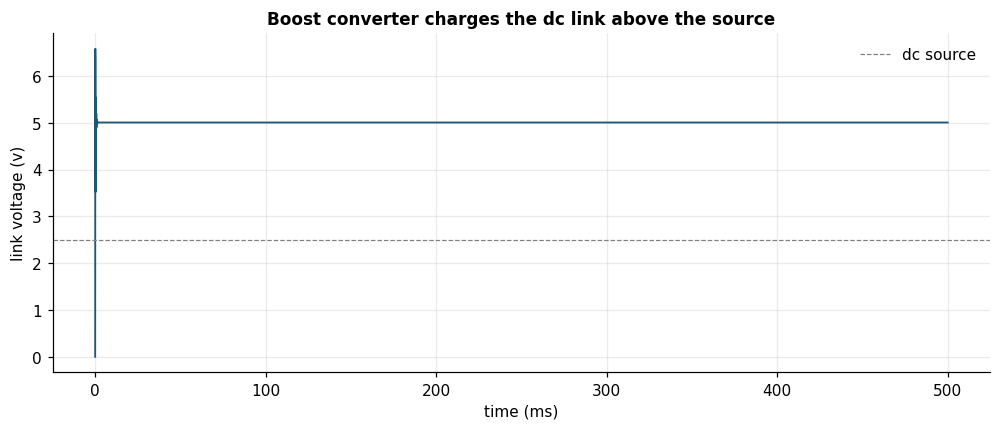

In [2]:
step = max(1, time.size // 6000)
t_thin, boost_thin = thin(time_ms, artifacts["boost_voltage"].astype(float), step=step)

fig, ax = plt.subplots()
ax.plot(t_thin, boost_thin, color=palette("boost"), lw=1.2)
ax.axhline(cfg.boost.input_voltage, color="grey", lw=0.8, ls="--", label="dc source")
ax.set_xlabel("time (ms)")
ax.set_ylabel("link voltage (v)")
ax.set_title("Boost converter charges the dc link above the source")
ax.legend()
save_figure(fig, "boost_link_voltage", cfg.paths.figures)
plt.show()

The link settles near 5 V, roughly double the 2.5 V source. That is the headroom
the bridge needs to synthesise a unit-amplitude sinusoid, and everything
downstream draws on this rail.

## The modulator chops the link into a pulse train

The sinusoidal-PWM output is a square wave switching between the link voltage,
zero and its negation, with the pulse widths set by a sine. A half-second view
would just be a solid block of switching, so this is a short window early in the
run, where the individual pulses and the sign reversal at the mains zero
crossing are actually visible.

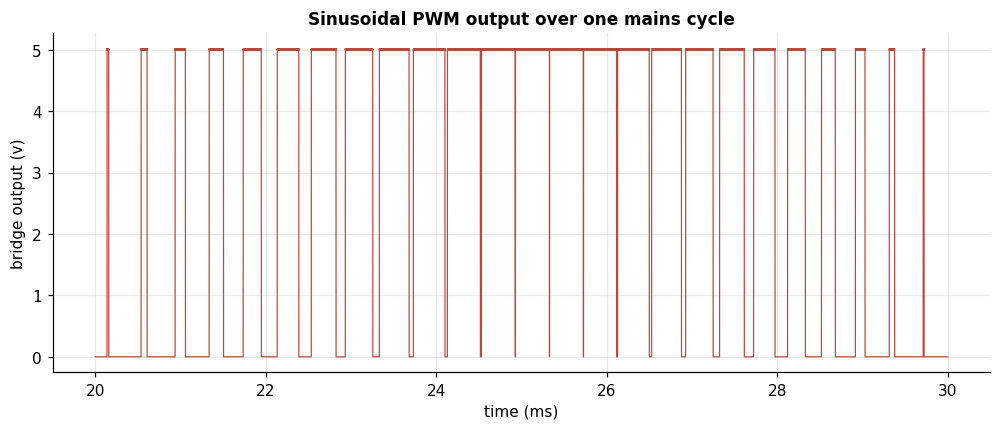

In [3]:
window = (time >= 0.020) & (time <= 0.030)
fig, ax = plt.subplots()
ax.plot(time_ms[window], artifacts["pwm_voltage"][window], color=palette("pwm"), lw=0.8)
ax.set_xlabel("time (ms)")
ax.set_ylabel("bridge output (v)")
ax.set_title("Sinusoidal PWM output over one mains cycle")
save_figure(fig, "pwm_output", cfg.paths.figures)
plt.show()

The pulses are densest where the sine is steepest and thin out near its peaks,
and the polarity flips with the half cycle. The modulator is encoding a 50 Hz
sinusoid in the widths of a high-frequency pulse train; the filter recovers it.

## The filtered output locks to the grid reference

The first-order filter, with its corner just above the mains line, passes the
synthesised sinusoid and rejects the ripple. Overlaid on the grid reference,
the filtered output starts out of step and is drawn into phase as the loop
acts. The amplitudes differ (the filtered output carries the link voltage, the
reference is unit amplitude), so watch the phase here, not the scale.

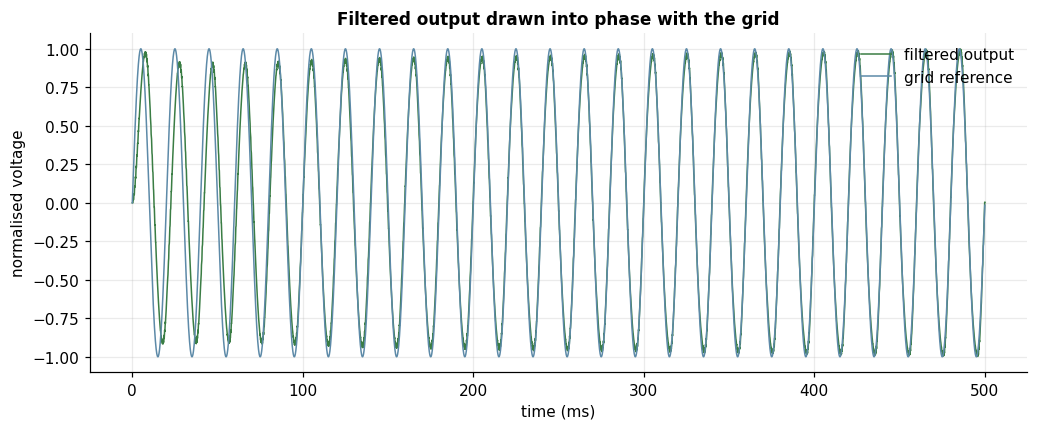

In [4]:
step = max(1, time.size // 8000)
t_thin, filt_thin, ref_thin = thin(
    time_ms,
    artifacts["filtered_voltage"].astype(float),
    artifacts["reference"].astype(float),
    step=step,
)
amplitude = meta["filtered_settled_amplitude"]

fig, ax = plt.subplots()
ax.plot(t_thin, filt_thin / amplitude, color=palette("filtered"), lw=1.0, label="filtered output")
ax.plot(t_thin, ref_thin, color=palette("reference"), lw=1.0, label="grid reference")
ax.set_xlabel("time (ms)")
ax.set_ylabel("normalised voltage")
ax.set_title("Filtered output drawn into phase with the grid")
ax.legend(loc="upper right")
save_figure(fig, "filtered_vs_reference", cfg.paths.figures)
plt.show()

Early in the run the two traces beat against each other; by the end they rise
and fall together. A close view of the settled tail confirms the alignment: the
zero crossings coincide, and the small residual is steady ripple, not drift.

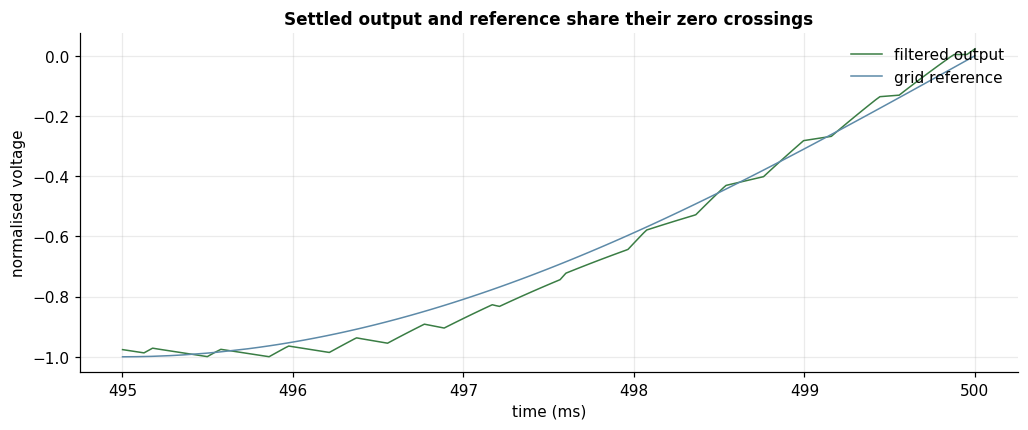

In [5]:
tail = slice(-25000, None)
fig, ax = plt.subplots()
ax.plot(
    time_ms[tail],
    artifacts["filtered_voltage"][tail].astype(float) / amplitude,
    color=palette("filtered"),
    lw=1.0,
    label="filtered output",
)
ax.plot(
    time_ms[tail],
    artifacts["reference"][tail].astype(float),
    color=palette("reference"),
    lw=1.0,
    label="grid reference",
)
ax.set_xlabel("time (ms)")
ax.set_ylabel("normalised voltage")
ax.set_title("Settled output and reference share their zero crossings")
ax.legend(loc="upper right")
plt.show()

## The phase-error signal converges

The loop's phase error is the correction it sends back to the modulator, so it
is the cleanest place to watch the lock happen. It overshoots as the loop first
catches the grid, then decays as the inverter settles into step, while the
ripple band around it narrows to a steady width. That narrowing is the lock
signature: the correction stops hunting and holds.

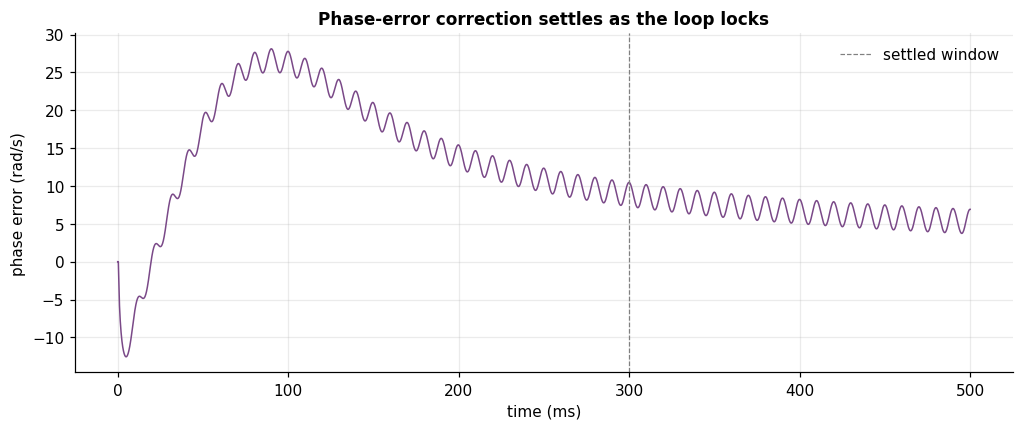

In [6]:
step = max(1, time.size // 8000)
t_thin, err_thin = thin(time_ms, artifacts["phase_error"].astype(float), step=step)

fig, ax = plt.subplots()
ax.plot(t_thin, err_thin, color=palette("error"), lw=1.0)
ax.axvline(time_ms[settle], color="grey", lw=0.8, ls="--", label="settled window")
ax.set_xlabel("time (ms)")
ax.set_ylabel("phase error (rad/s)")
ax.set_title("Phase-error correction settles as the loop locks")
ax.legend()
save_figure(fig, "phase_error", cfg.paths.figures)
plt.show()

The ripple spread drops sharply between the transient and the locked window,
alongside the dc-link voltage and the integration cost, all in the run metadata
below.

In [7]:
pd.Series(
    {
        "transient phase-error std (rad/s)": meta["phase_error_transient_std"],
        "locked phase-error std (rad/s)": meta["phase_error_locked_std"],
        "locked phase-error mean (rad/s)": meta["phase_error_locked_mean"],
        "boost link voltage (v)": meta["boost_final_voltage"],
        "integration runtime (s)": meta["runtime_s"],
    }
).round(3).to_frame("value")

,value
transient phase-error std (rad/s),8.573
locked phase-error std (rad/s),1.522
locked phase-error mean (rad/s),6.765
boost link voltage (v),4.994
integration runtime (s),8.643


## The spectrum of the settled output

A frequency view of the settled output is the cleanest test of lock. If the
inverter has matched the grid, its spectrum should concentrate at 50 Hz, with
the switching harmonics decades higher and the rest of the band empty. The
transform runs over the settled tail only, with its mean removed.

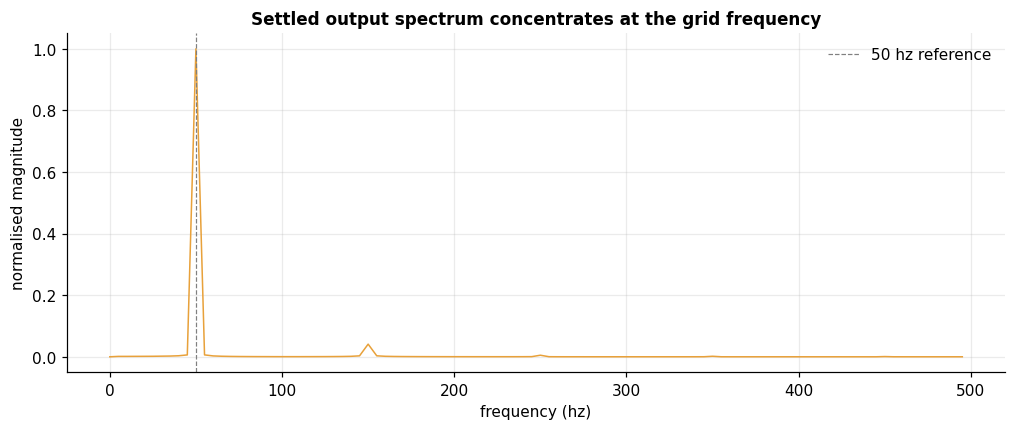

In [8]:
settled = artifacts["filtered_voltage"][settle:].astype(float)
settled = settled - settled.mean()
spectrum = np.abs(np.fft.rfft(settled))
frequency = np.fft.rfftfreq(settled.size, d=dt)
spectrum = spectrum / spectrum.max()

band = frequency <= 500
dominant = frequency[np.argmax(spectrum)]

fig, ax = plt.subplots()
ax.plot(frequency[band], spectrum[band], color=palette("spectrum"), lw=1.0)
ax.axvline(cfg.grid.frequency, color="grey", lw=0.8, ls="--", label="50 hz reference")
ax.set_xlabel("frequency (hz)")
ax.set_ylabel("normalised magnitude")
ax.set_title("Settled output spectrum concentrates at the grid frequency")
ax.legend()
save_figure(fig, "output_spectrum", cfg.paths.figures)
plt.show()

The peak lands on the grid frequency, with weak odd harmonics at 150 and 250 Hz
from the residual switching content. The inverter output is, to a good
approximation, a single tone at the grid line.

In [9]:
print(f"dominant settled component: {dominant:.1f} Hz")

dominant settled component: 50.0 Hz


## Summary

- The boost stage lifts the 2.5 V source to a roughly 5 V dc link, the headroom
  the bridge needs to synthesise a unit-amplitude sinusoid.
- The sinusoidal-PWM modulator encodes a 50 Hz waveform in the widths of a
  2 MHz pulse train, recovered by the first-order output filter.
- The PLL pulls the filtered output into step with the grid reference: the two
  share their zero crossings once the loop settles.
- The phase-error correction overshoots, then decays to a steady value with a
  narrow ripple band, which is the lock signature.
- The settled output spectrum concentrates at 50 Hz with only weak switching
  harmonics, confirming the inverter has synchronised to the grid.